In [3]:
# https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html
import torch
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix

# Load CIFAR10
train_data = datasets.CIFAR10(root="data", train=True, download=True, transform=transforms.ToTensor())
test_data = datasets.CIFAR10(root="data", train=False, download=True, transform=transforms.ToTensor())
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)
# Set device to 'cuda' if available, otherwise 'cpu'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(train_data.data.shape)
for X,y in test_loader:
    print(f"shape of X : {X.shape}")
    print(f"shape of y : {y.shape} {y.dtype}")
    break

# Define MLP
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*32*3, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x):
        return self.layers(x)

model = MLP().to(device)
print(model)
print(model.parameters())
print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)


def train(dataloader, model, loss_fun, optimizer):
    # training the model
    size = len(dataloader.dataset)
    model.train()
    for batch, (X,y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        pred = model(X)
        pred_prob = nn.Softmax(dim=1)(pred)
        loss = loss_fn(pred,y)

        #Backprop
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f} [{current:>5d}/{size:>5d}]")

def test(dataloader, model, loss_fun):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            pred_prob = nn.Softmax(dim=1)(pred)
            test_loss += loss_fun(pred_prob, y).item()
            correct += (pred_prob.argmax(1)==y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:8f} \n")

Using device: cpu
(50000, 32, 32, 3)
shape of X : torch.Size([64, 3, 32, 32])
shape of y : torch.Size([64]) torch.int64
MLP(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)
<generator object Module.parameters at 0x7f3f5c8b98c0>
Model structure: MLP(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)


Layer: layers.1.weight | Size: torch.Size([64, 3072]) | Values : tensor([[ 0.0084,  0.0165, -0.0122,  ...,  0.0128,  0.0081, -0.0055],
        [-0.0014, -0.0019,  0.0104,  ...,  0.0163,  0.0090, -0.0107]],
       grad_fn=<SliceBackward0>) 

Layer: layers.1.bias | Size: torch.Size([64]) | Values : tensor([0.0054, 0.0175], grad_fn=<SliceBackward0>) 

Layer: layers.3.weight | 

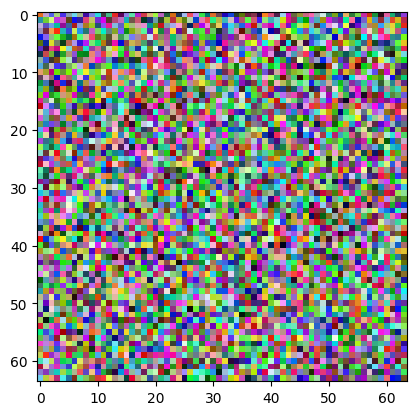

In [41]:
# noise test image
test_image = torch.rand(1,3,64,64)
test_image_np = test_image.squeeze(0).permute(1,2,0).numpy()
plt.imshow(test_image_np)

Text(0.5, 1.0, 'bird')

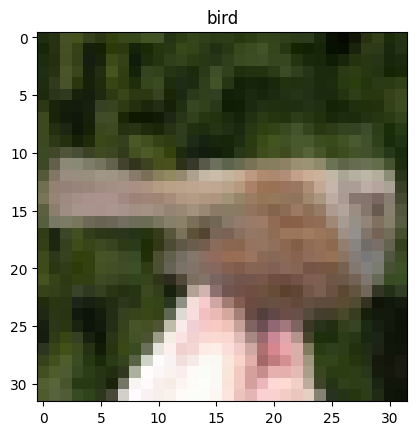

In [42]:
# data test image 
labels_map = train_data.classes
index = torch.randint(len(train_data), size=(1,)).item()
example_image, label = train_data[index]
# changing indices to fit imshow
example_image_permuted = example_image.squeeze(0).permute(1,2,0).numpy()
plt.imshow(example_image_permuted)
plt.title(labels_map[label])

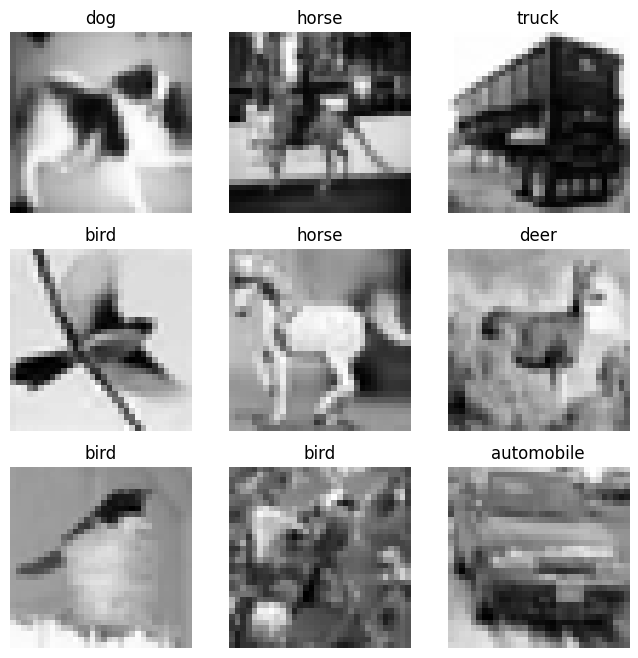

In [43]:
labels_map = train_data.classes
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img[0], cmap='gray')
plt.show()

In [49]:
X = test_loader
X.dataset.data.shape

(10000, 32, 32, 3)

157

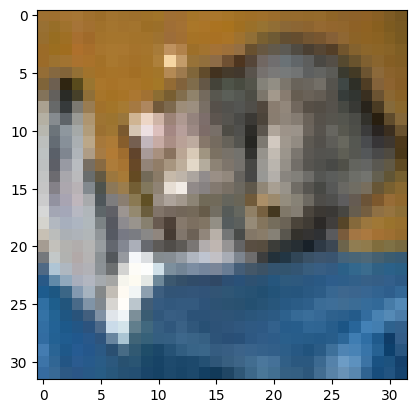

In [54]:
# data loader swaps indices 
plt.imshow(X.dataset.data[0])

In [25]:
epochs = 2

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_loader, model, loss_fn, optimizer)
    test(test_loader, model, loss_fn)
print("Done")

Epoch 1
-------------------------------
loss: 2.307235 [   64/50000]
loss: 2.287934 [ 6464/50000]
loss: 2.270909 [12864/50000]
loss: 2.261176 [19264/50000]
loss: 2.259595 [25664/50000]
loss: 2.242213 [32064/50000]
loss: 2.214420 [38464/50000]
loss: 2.227026 [44864/50000]
test Error: 
 Accuracy: 20.3%, Avg loss: 2.290041 

Epoch 2
-------------------------------
loss: 2.191061 [   64/50000]
loss: 2.193305 [ 6464/50000]
loss: 2.160077 [12864/50000]
loss: 2.151603 [19264/50000]
loss: 2.135931 [25664/50000]
loss: 2.200828 [32064/50000]
loss: 2.071076 [38464/50000]
loss: 2.068409 [44864/50000]
test Error: 
 Accuracy: 25.1%, Avg loss: 2.276646 

Done


In [58]:
classes = test_data.classes

# making on prediction
model.eval()
x, y = test_data[0]
with torch.no_grad():
    x = x.to(device)
    pred = model(x)
    pred_prob = nn.Softmax(dim=1)(pred)
    predicted, actual = classes[pred_prob[0].argmax(0)], classes[y]
    print(f'Predicted: "{predicted}", Actual "{actual}"')

RuntimeError: mat1 and mat2 shapes cannot be multiplied (3x1024 and 3072x64)